# 제주도 농산물 가격 예측 데이터 분석 (EDA)

## 1. 데이터 컬럼 설명

### train.csv : 학습 데이터
- `ID`: 각 거래의 고유 ID (품목_법인_지역_날짜 조합)
- `timestamp`: 거래가 이루어진 날짜
- `item`: 품목 (TG: 감귤, CR: 당근, CB: 양배추, RD: 무, BC: 브로콜리)
- `corporation`: 유통 법인 (A~F)
- `location`: 지역 (J: 제주, S: 서귀포)
- `supply(kg)`: 해당 날짜의 공급량 (kg)
- `price(원/kg)`: 해당 날짜의 단가 (원/kg) **[Target]**

### test.csv : 테스트 데이터
- `ID`: 각 거래의 고유 ID
- `timestamp`: 거래가 이루어진 날짜 (2023-03-04 ~ 2023-03-31)
- `item`: 품목
- `corporation`: 유통 법인
- `location`: 지역

### sample_submission.csv : 제출 양식
- `ID`: 각 거래의 고유 ID
- `answer`: 예측한 단가 (원/kg)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from korean_font import set_korean_font

# 한글 폰트 설정
set_korean_font()

# 데이터 불러오기
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

print("Train Data Shape:", train.shape)
print("Test Data Shape:", test.shape)
train.head()

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
Train Data Shape: (59397, 7)
Test Data Shape: (1092, 5)


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg)
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0


## 2. 결측치 확인

In [2]:
print("--- Train Missing Values ---")
print(train.isnull().sum())
print("\n--- Test Missing Values ---")
print(test.isnull().sum())

--- Train Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
supply(kg)     0
price(원/kg)    0
dtype: int64

--- Test Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
dtype: int64


## 3. 품목별 평균 가격 시각화

/tmp/ipykernel_77110/136372869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='item', y='price(원/kg)', data=train, palette='viridis')


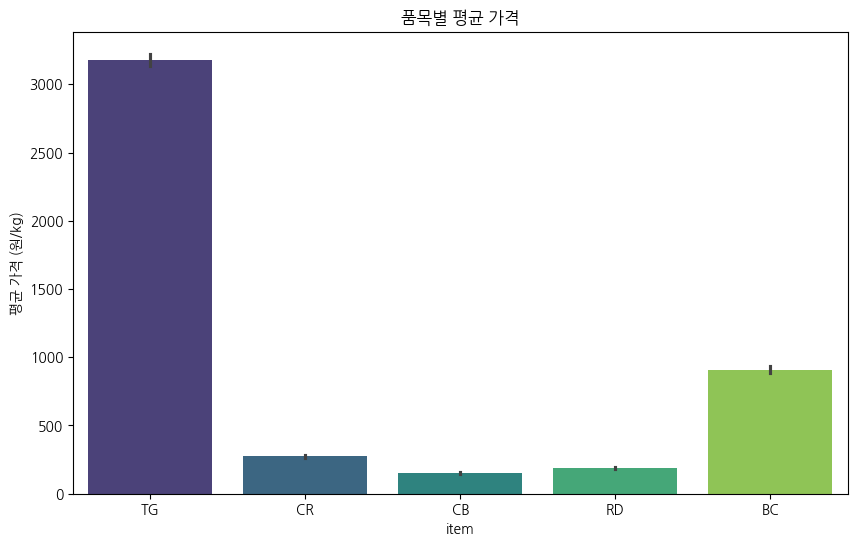

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(x='item', y='price(원/kg)', data=train, palette='viridis')
plt.title('품목별 평균 가격')
plt.ylabel('평균 가격 (원/kg)')
plt.show()

## 4. 이상치 확인 (Boxplot)

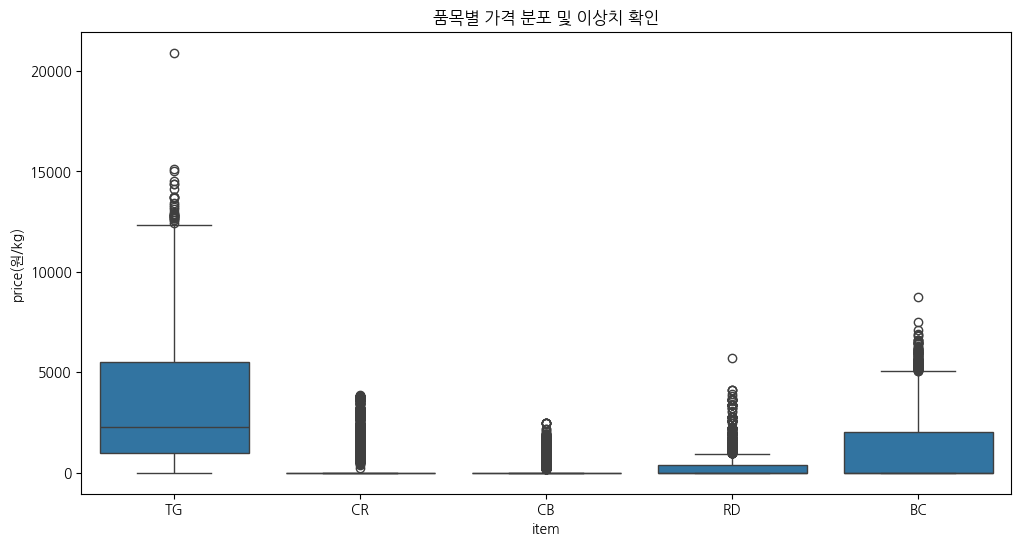

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='item', y='price(원/kg)', data=train)
plt.title('품목별 가격 분포 및 이상치 확인')
plt.show()

## 5. 품목별 시계열 가격 추이

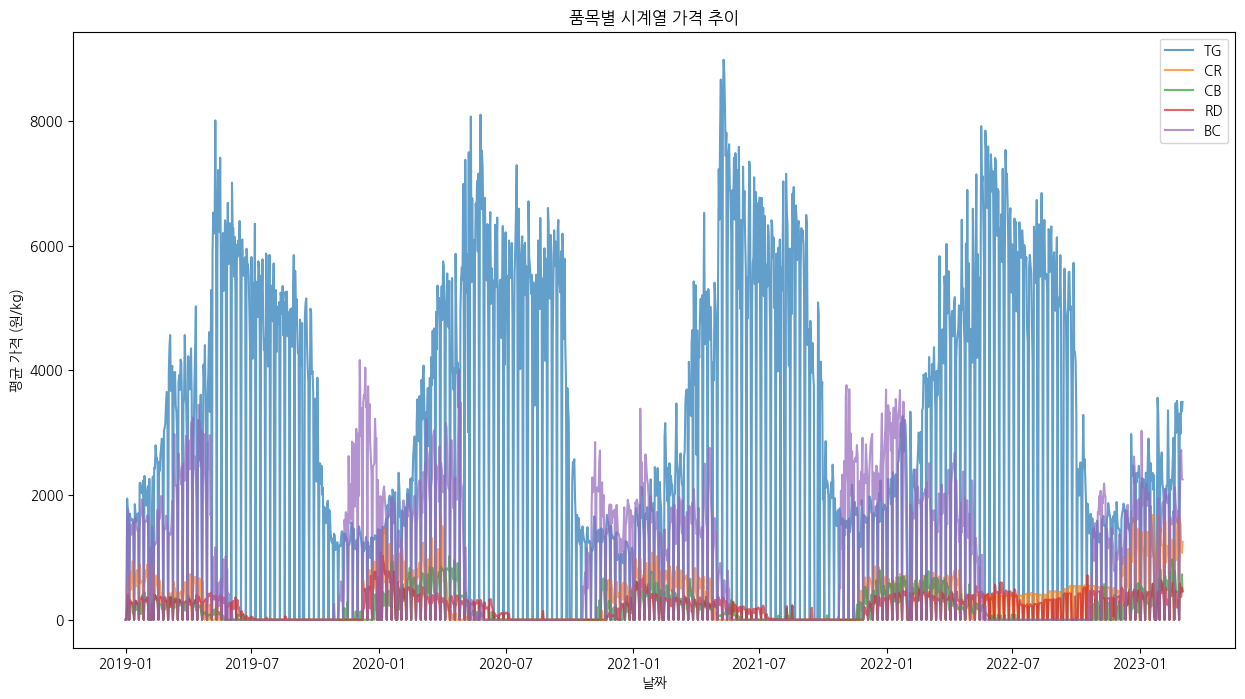

In [5]:
train['timestamp'] = pd.to_datetime(train['timestamp'])

plt.figure(figsize=(15, 8))
for item in train['item'].unique():
    item_data = train[train['item'] == item].groupby('timestamp')['price(원/kg)'].mean()
    plt.plot(item_data.index, item_data.values, label=item, alpha=0.7)

plt.title('품목별 시계열 가격 추이')
plt.xlabel('날짜')
plt.ylabel('평균 가격 (원/kg)')
plt.legend()
plt.show()

## 6. 연도별 평균 가격 분석

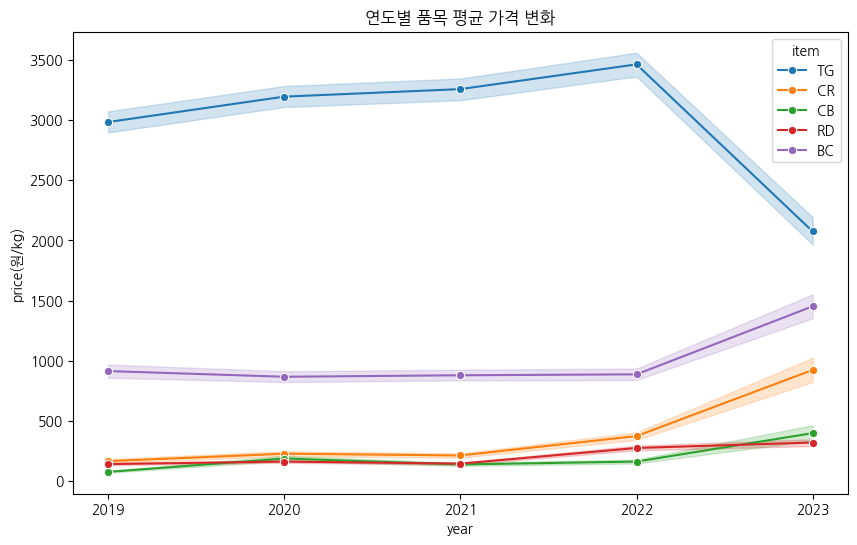

In [6]:
train['year'] = train['timestamp'].dt.year

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='price(원/kg)', hue='item', data=train, marker='o')
plt.title('연도별 품목 평균 가격 변화')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.show()

## 7. 계절성 분석 (월별 평균 가격)

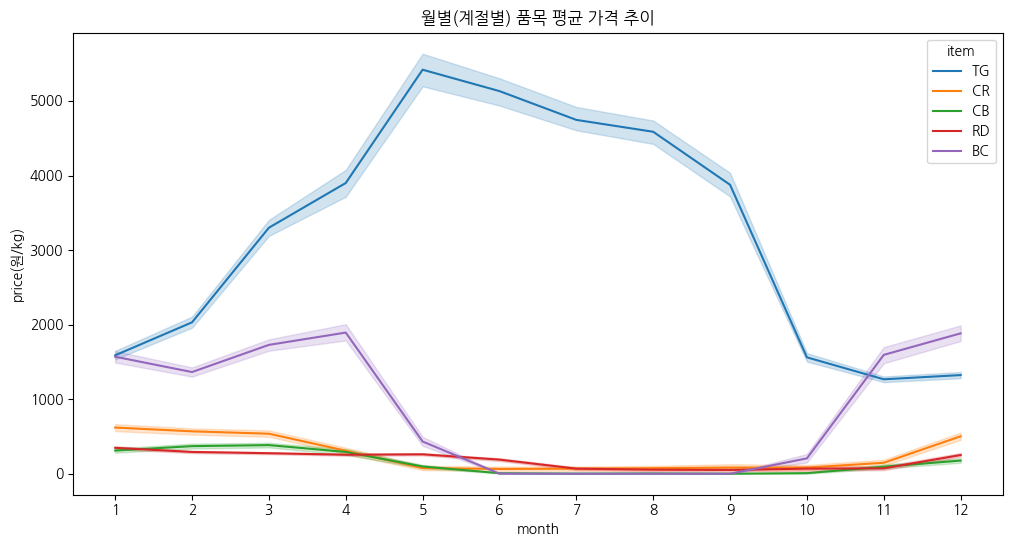

In [7]:
train['month'] = train['timestamp'].dt.month

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='price(원/kg)', hue='item', data=train)
plt.title('월별(계절별) 품목 평균 가격 추이')
plt.xticks(range(1, 13))
plt.show()

## 8. 이상기후 영향 분석 (급격한 가격 변동 확인)
이상기후는 특정 시점의 공급량(supply) 급감과 가격(price) 급등으로 나타날 수 있습니다.

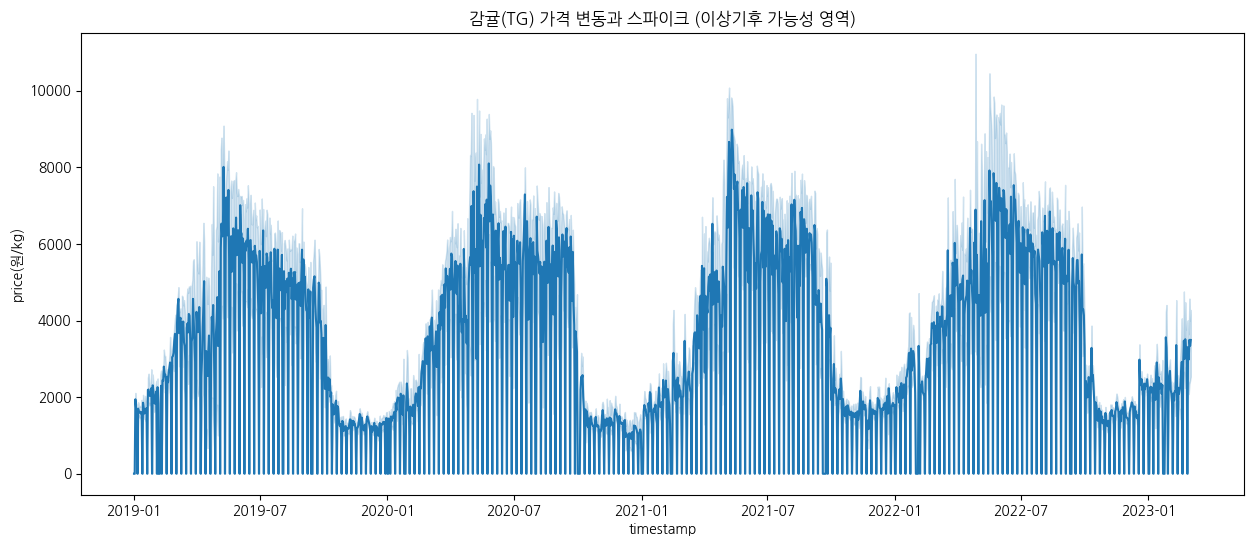

In [8]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y='price(원/kg)', data=train[train['item']=='TG'])
plt.title('감귤(TG) 가격 변동과 스파이크 (이상기후 가능성 영역)')
plt.show()

## 9. 요일별 판매량 및 가격 분석 (일요일 0원 현상)
일요일에는 경매가 열리지 않아 가격이 0원인 경우가 많습니다.

/tmp/ipykernel_77110/807359854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_supply.index, y=avg_supply.values, palette='Blues_d', ax=axes[0])
/tmp/ipykernel_77110/807359854.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='Greens_d', ax=axes[1])


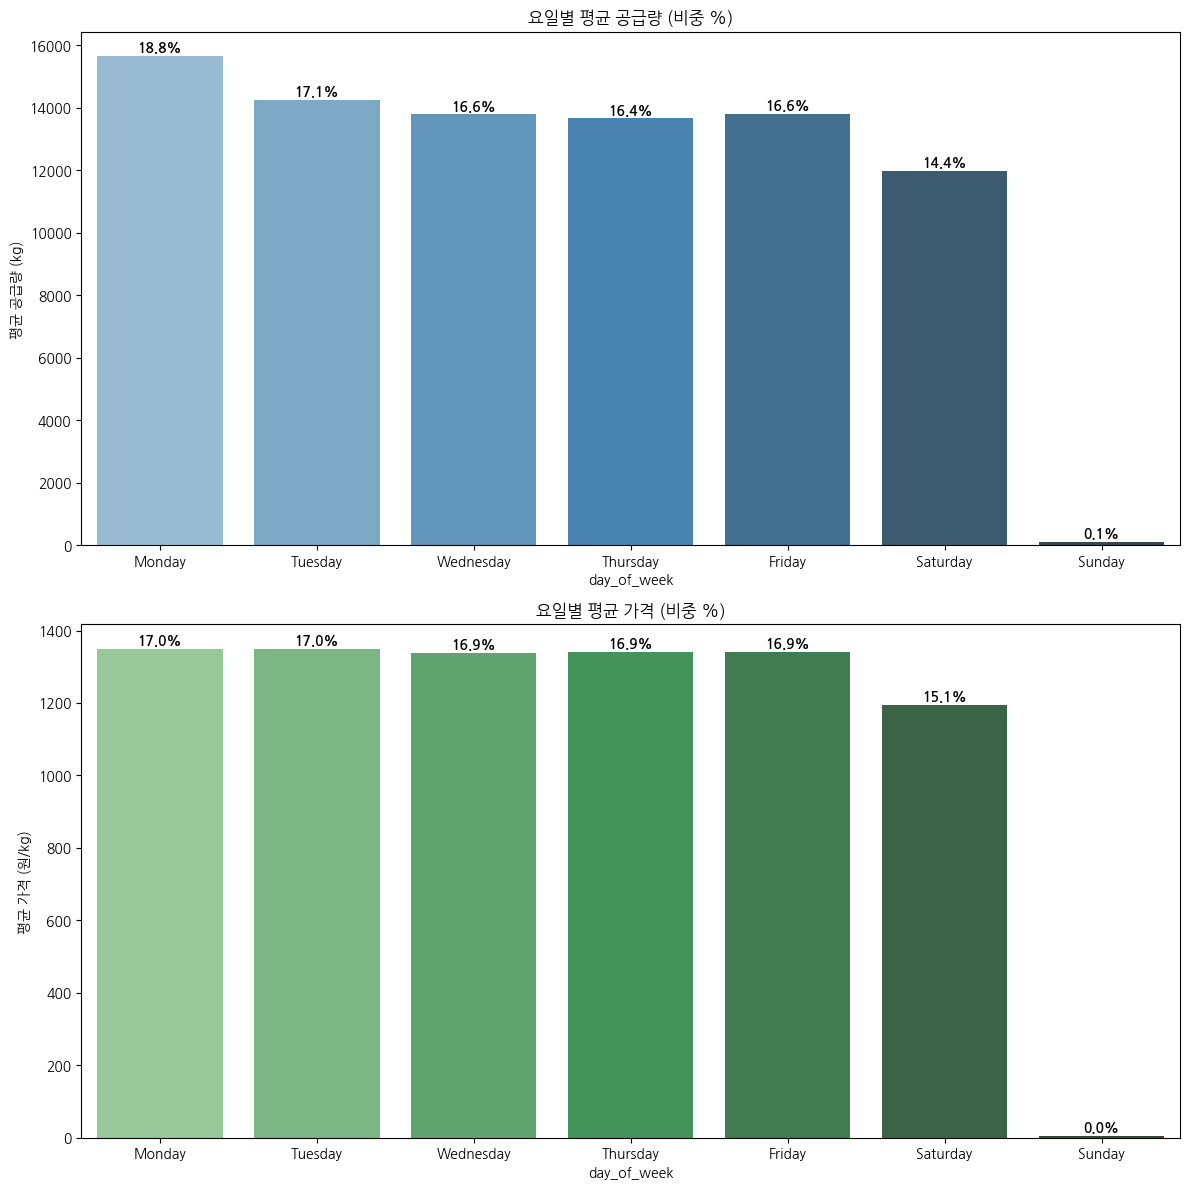

In [9]:
train['day_of_week'] = train['timestamp'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. 요일별 평균 공급량
avg_supply = train.groupby('day_of_week')['supply(kg)'].mean().reindex(order)
total_avg_supply = avg_supply.sum()

sns.barplot(x=avg_supply.index, y=avg_supply.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('요일별 평균 공급량 (비중 %)')
axes[0].set_ylabel('평균 공급량 (kg)')

# 퍼센트 표시
for i, val in enumerate(avg_supply.values):
    percentage = (val / total_avg_supply) * 100
    axes[0].text(i, val + (avg_supply.max()*0.01), f'{percentage:.1f}%', ha='center', fontweight='bold')

# 2. 요일별 평균 가격
avg_price = train.groupby('day_of_week')['price(원/kg)'].mean().reindex(order)
total_avg_price = avg_price.sum()

sns.barplot(x=avg_price.index, y=avg_price.values, palette='Greens_d', ax=axes[1])
axes[1].set_title('요일별 평균 가격 (비중 %)')
axes[1].set_ylabel('평균 가격 (원/kg)')

# 퍼센트 표시
for i, val in enumerate(avg_price.values):
    percentage = (val / total_avg_price) * 100
    axes[1].text(i, val + (avg_price.max()*0.01), f'{percentage:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. 한국 명절(설날, 추석) 효과 분석
농산물 가격은 설날과 추석 명절 전 수요 급증으로 인해 가격이 상승하는 경향이 있습니다.

### 왜 명절 당일에 가격이 가장 낮을까요?
1. **도매시장 휴장 (가장 큰 이유)**: 한국의 주요 농산물 도매시장(가락시장 등)은 설날과 추석 연휴 기간에 경매를 쉽니다. 경매가 열리지 않으니 거래량이 0이 되고, 데이터상에는 0원 혹은 아주 낮은 가격으로 기록되는 것입니다.
2. **수요의 선반영**: 명절에 쓸 제수용품이나 선물 세트는 명절 당일이 아니라, 명절 1~2주 전에 이미 구매가 완료됩니다. 그래서 명절 직전까지 가격이 치솟다가 당일에는 거래 자체가 끊기게 됩니다.

/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


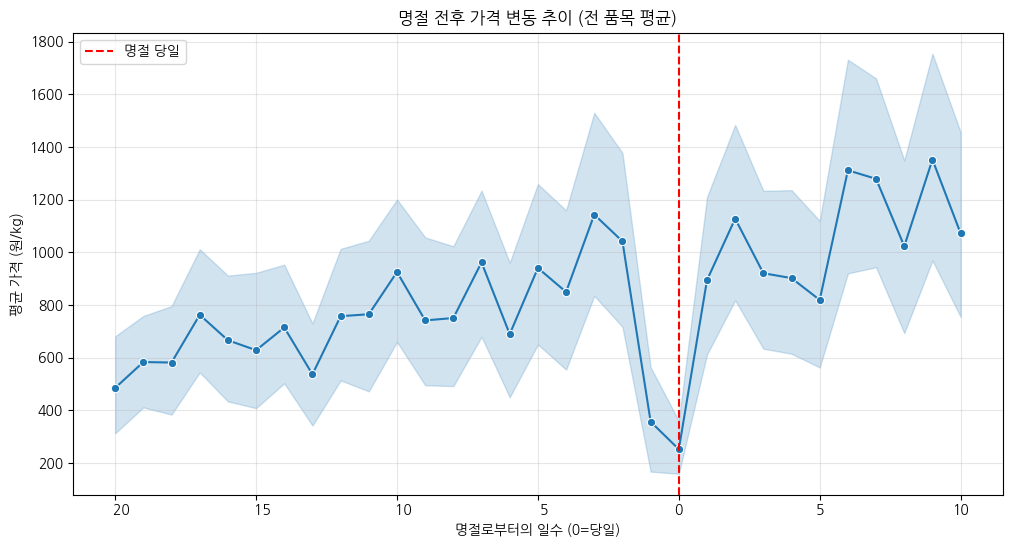

In [10]:
import holidays

kr_holidays = holidays.KR()

# 명절(설날, 추석) 날짜 추출 함수
def get_traditional_holidays(start_year, end_year):
    traditional_holidays = []
    for year in range(start_year, end_year + 1):
        for date, name in sorted(holidays.KR(years=year).items()):
            if 'Lunar New Year' in name or 'Chuseok' in name:
                traditional_holidays.append(date)
    return traditional_holidays

holiday_dates = get_traditional_holidays(2019, 2023)

def calculate_dist_to_holiday(date):
    diffs = [(pd.Timestamp(h) - date).days for h in holiday_dates]
    min_diff = min(diffs, key=abs)
    return min_diff

train_holiday = train.copy()
train_holiday['dist_to_holiday'] = train_holiday['timestamp'].apply(calculate_dist_to_holiday)

plt.figure(figsize=(12, 6))
mask = (train_holiday['dist_to_holiday'] >= -20) & (train_holiday['dist_to_holiday'] <= 10)
sns.lineplot(x='dist_to_holiday', y='price(원/kg)', data=train_holiday[mask], marker='o')
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 추이 (전 품목 평균)')
plt.xlabel('명절로부터의 일수 (0=당일)')
plt.ylabel('평균 가격 (원/kg)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 11. 유통법인(Corporation)별 특성 분석
각 유통법인(A~F)별로 취급하는 품목의 비중이나 경매 낙찰 단가가 다를 수 있습니다.

/tmp/ipykernel_77110/3327069247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='corporation', data=train, palette='Set2', ax=axes[0])
/tmp/ipykernel_77110/3327069247.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='corporation', y='price(원/kg)', data=train, palette='Set2', ax=axes[1])


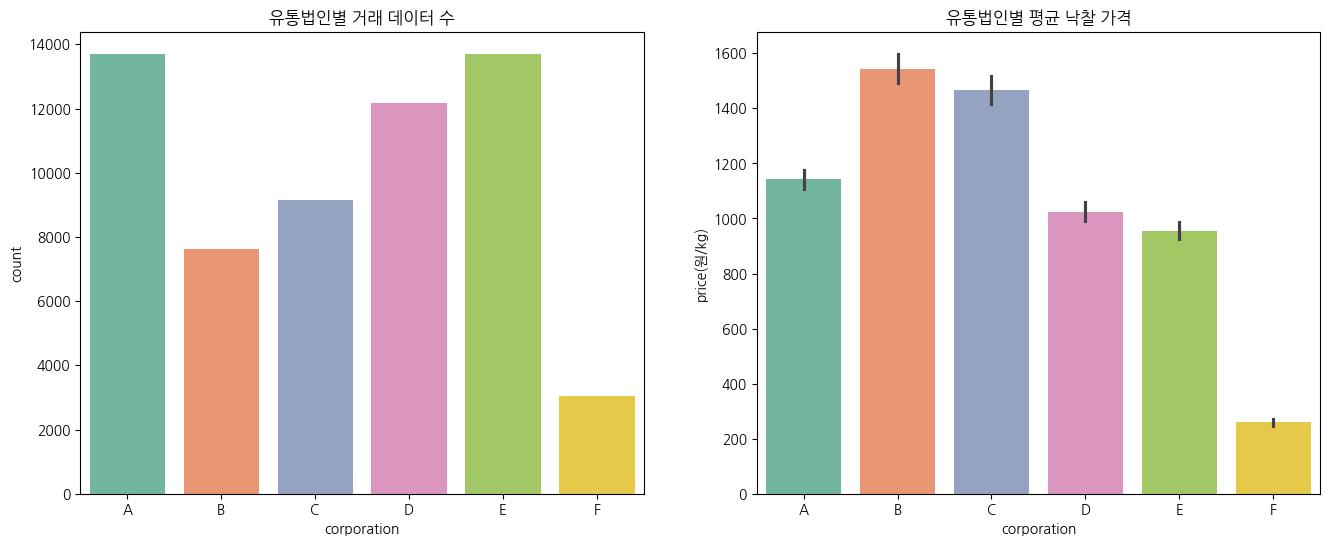

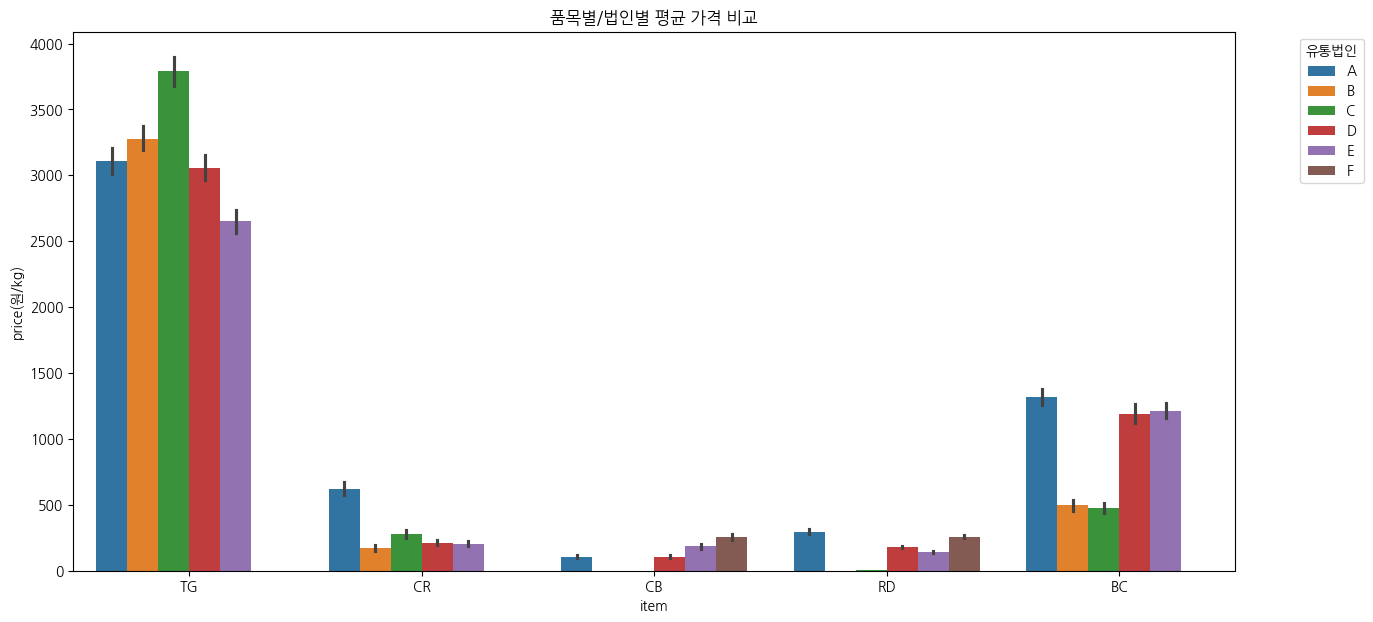

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='corporation', data=train, palette='Set2', ax=axes[0])
axes[0].set_title('유통법인별 거래 데이터 수')

sns.barplot(x='corporation', y='price(원/kg)', data=train, palette='Set2', ax=axes[1])
axes[1].set_title('유통법인별 평균 낙찰 가격')

plt.show()

plt.figure(figsize=(15, 7))
sns.barplot(x='item', y='price(원/kg)', hue='corporation', data=train)
plt.title('품목별/법인별 평균 가격 비교')
plt.legend(title='유통법인', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 12. 공급량(Supply)과 가격(Price)의 상관관계 분석
일반적으로 공급량이 늘어나면 가격이 하락하는 반비례 관계가 성립합니다. 품목별로 이 관계가 얼마나 뚜렷한지 확인합니다.

--- 품목별 공급량-가격 상관계수 ---
TG: -0.5220
CR: -0.2526
CB: -0.1271
RD: -0.1293
BC: -0.1540


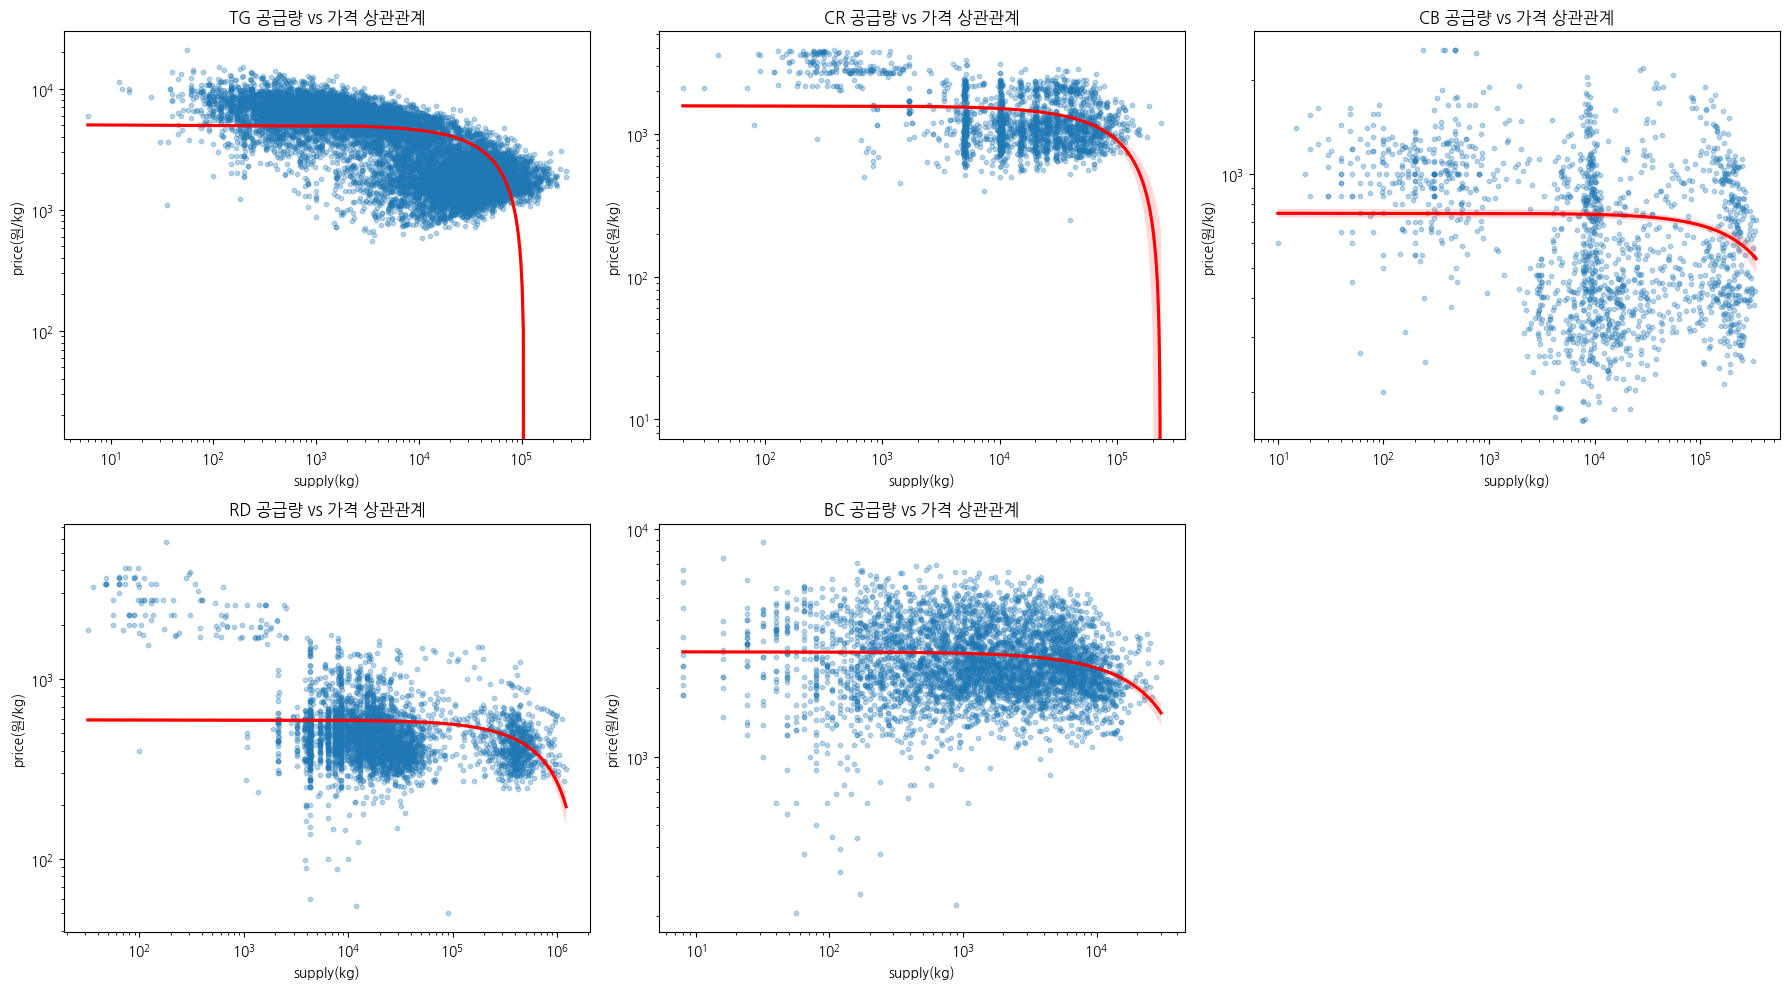

In [12]:
import matplotlib.ticker as ticker

print("--- 품목별 공급량-가격 상관계수 ---")
for item in train['item'].unique():
    item_df = train[(train['item'] == item) & (train['price(원/kg)'] > 0) & (train['supply(kg)'] > 0)]
    corr = item_df['supply(kg)'].corr(item_df['price(원/kg)'])
    print(f"{item}: {corr:.4f}")

plt.figure(figsize=(18, 10))
items = train['item'].unique()
for i, item in enumerate(items):
    ax = plt.subplot(2, 3, i+1)
    item_df = train[(train['item'] == item) & (train['price(원/kg)'] > 0) & (train['supply(kg)'] > 0)]
    sns.regplot(x='supply(kg)', y='price(원/kg)', data=item_df, 
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    
    plt.title(f'{item} 공급량 vs 가격 상관관계')
    plt.xscale('log')
    plt.yscale('log')
    
    # 축 단위 보기 쉽게 변경 (10^n -> 일반 숫자)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}' if x >= 1 else f'{x:.1f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(y):,}' if y >= 1 else f'{y:.1f}'))
    
plt.tight_layout()
plt.show()

### 💡 상관계수 및 산점도 해석 방법

1.  **상관계수 ($r$)**: -1에서 1 사이의 값을 가집니다.
    *   **음수 (-)**: 한쪽이 커지면 다른 쪽은 작아지는 관계입니다. 농산물은 **"공급이 늘면 가격이 떨어진다"**는 경제 원칙에 따라 보통 음수가 나옵니다.
    *   **-0.5 이하**: 꽤 뚜렷한 반비례 관계입니다. (예: 감귤(TG)은 공급량 관리가 가격에 매우 중요함)
    *   **0에 가까움**: 공급량 외에 다른 요인(수입량, 명절 특수성, 품질 등)이 가격 결정에 더 크게 작용함을 의미합니다.
2.  **로그 스케일 그래프**: 데이터가 특정 구간(낮은 가격대)에 너무 몰려 있으면 추세를 보기 어렵기 때문에, 축 간격을 조정하여 전체적인 흐름(빨간 선)을 더 명확히 보기 위해 사용합니다.
3.  **빨간 실선**: 공급량에 따른 가격의 평균적인 변화 추세입니다. 이 선이 가파르게 내려갈수록 공급량 변화에 가격이 민감하게 반응하는 품목입니다.

## 13. 외부 데이터 분석 (international_trade.csv)
수출입 데이터가 국내 농산물 가격에 미치는 영향을 분석합니다. 특히 수입량이 많은 품목은 국내 가격 하락의 요인이 될 수 있습니다.

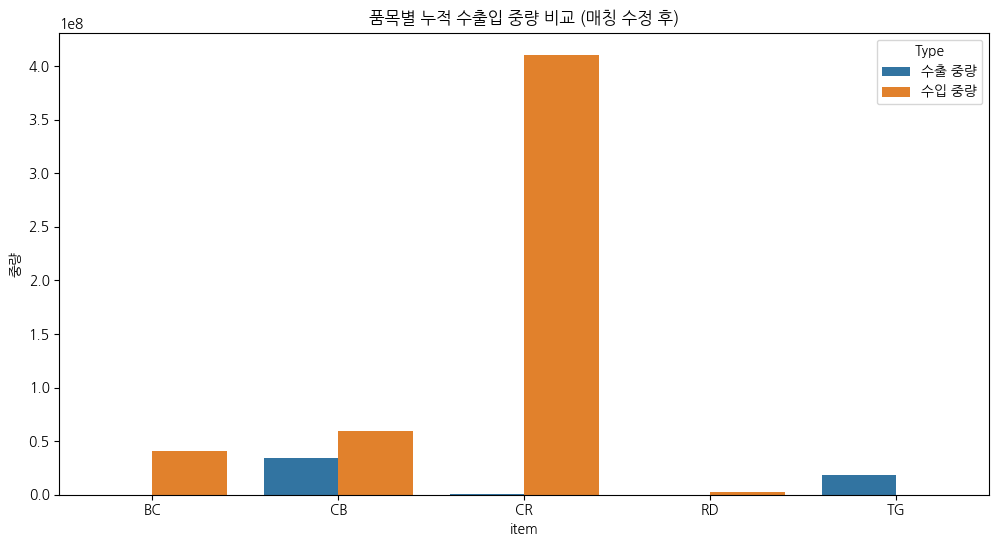

/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


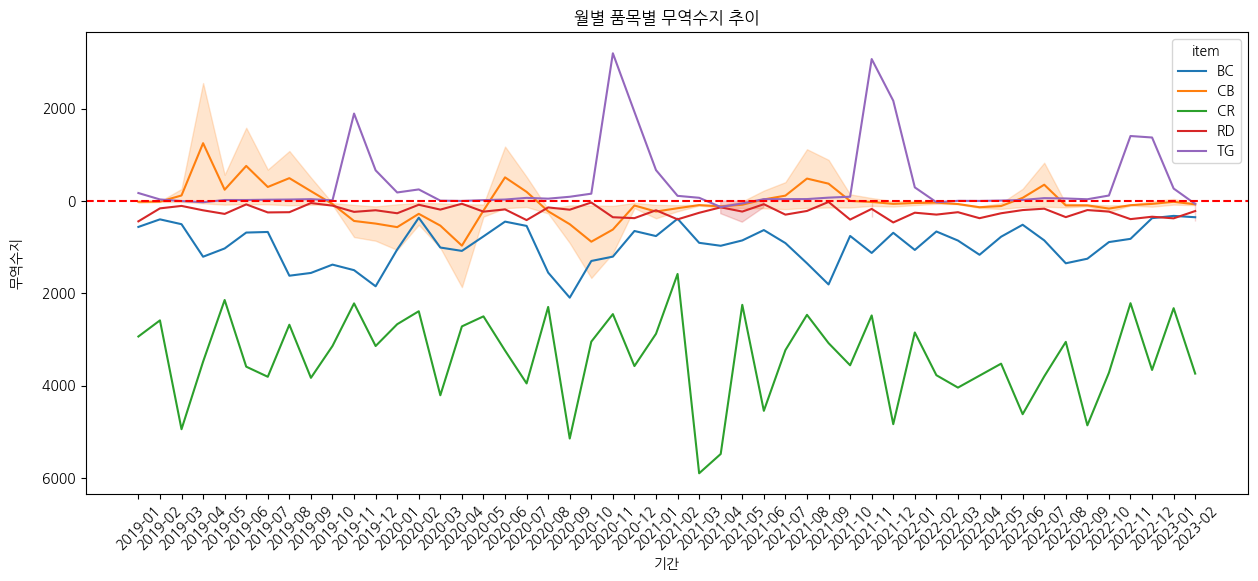

In [13]:
trade = pd.read_csv('international_trade.csv')

item_map = {
    '브로콜리': 'BC',
    '감귤': 'TG', 
    '당근': 'CR', 
    '양배추': 'CB', 
    '무': 'RD'
}

def map_item(name):
    for k, v in item_map.items():
        if k in name: return v
    return 'Others'

trade['item'] = trade['품목명'].apply(map_item)
trade = trade[trade['item'] != 'Others']

trade_summary = trade.groupby('item')[['수출 중량', '수입 중량']].sum().reset_index()
plt.figure(figsize=(12, 6))
trade_summary_melted = trade_summary.melt(id_vars='item', var_name='Type', value_name='Weight')
sns.barplot(x='item', y='Weight', hue='Type', data=trade_summary_melted)
plt.title('품목별 누적 수출입 중량 비교 (매칭 수정 후)')
plt.ylabel('중량')
plt.show()

plt.figure(figsize=(15, 6))
sns.lineplot(x='기간', y='무역수지', hue='item', data=trade)
plt.title('월별 품목별 무역수지 추이')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--')
plt.show()

### 13.1 외부 데이터 분석 결과 해석 및 인사이트

1. **품목별 수출입 구조 차이**:
   - **TG(감귤)**: 수입량은 거의 없으며 수출량이 압도적입니다. 이는 국내 가격 방어에 긍정적인 요인으로 작용합니다.
   - **BC(브로콜리) & CR(당근)**: 수출보다 수입 중량이 훨씬 높습니다. 특히 브로콜리는 수입 의존도가 높아, 해외 수입 시세나 수입량이 국내산 낙찰 단가 하락의 주요 압박 요인이 될 수 있습니다.
   - **CB(양배추) & RD(무)**: 상대적으로 수출입 비중이 낮으나 특정 시즌에 따라 무역수지가 변동하는 패턴을 보입니다.

2. **무역수지와 국내 가격의 상관성**:
   - 무역수지가 마이너스(수입 증가)로 깊어지는 구간은 국내 공급 부족을 메우기 위한 수입이 발생하는 시기일 가능성이 높습니다.
   - 이 데이터는 국내 `supply(kg)` 데이터만으로는 파악하기 어려운 **'전체 시장 공급량'**의 보조 지표로 활용될 수 있습니다.

## 14. 이상치 처리 및 파생 변수 생성 (Preprocessing & Feature Engineering)

기존 시계열 변수에 더해 **데이콘 1위 솔루션**에서 사용된 고도화된 기법들을 추가로 적용합니다.

In [14]:
import holidays
from sklearn.preprocessing import LabelEncoder

def create_advanced_features(df, is_train=True):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 기본 시간 변수
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_sunday'] = (df['day_of_week'] == 6).astype(int)
    
    # 1. 연속 주차 변수 (week_num) [데이콘 참조]
    # 2019-01-01을 기준으로 전체 기간에 대해 끊기지 않는 주차 번호 부여
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    
    # 2. 정교한 공휴일 및 휴무일 보정 [데이콘 참조]
    kr_holidays = holidays.KR()
    df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
    
    # 공휴일이지만 실제 거래량이 발생한 날은 휴무가 아니라고 판단하여 0으로 수정
    if is_train and 'supply(kg)' in df.columns:
        df.loc[(df['is_holiday'] == 1) & (df['supply(kg)'] > 0), 'is_holiday'] = 0
    
    # 3. 감귤(TG) 고가 시즌 및 명절 변수 (기존 로직 유지)
    df['is_high_price_season'] = 0
    df.loc[(df['item'] == 'TG') & (df['month'].isin([5, 6, 7, 8, 9])), 'is_high_price_season'] = 1
    
    # 4. 연-월 라벨 인코딩 [데이콘 참조]
    df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
    le = LabelEncoder()
    df['year_month_idx'] = le.fit_transform(df['year_month'])
    
    return df

train = create_advanced_features(train, is_train=True)
test = create_advanced_features(test, is_train=False)

print("고도화된 파생 변수 생성 완료 (week_num, 정교한 공휴일 보정 포함)")
train.head()

고도화된 파생 변수 생성 완료 (week_num, 정교한 공휴일 보정 포함)


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg),year,month,day_of_week,day,is_sunday,week_num,is_holiday,is_high_price_season,year_month,year_month_idx
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,2019,1,1,1,0,0,1,0,2019-01,0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,2019,1,2,2,0,0,0,0,2019-01,0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,2019,1,3,3,0,0,0,0,2019-01,0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0,2019,1,4,4,0,0,0,0,2019-01,0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0,2019,1,5,5,0,0,0,0,2019-01,0


### 14.1 품목별 이상치 캡핑 (Outlier Capping) [데이콘 참조]

모델이 극단적인 가격에 휘둘리지 않도록 품목별로 상한선을 설정하여 전처리합니다.

In [15]:
# 품목별 최대 가격 제한 (분석된 임계값 적용)
capping_dict = {
    'TG': 20000, # 감귤
    'CR': 5000,  # 당근
    'CB': 3000,  # 양배추
    'RD': 4000,  # 무
    'BC': 8000   # 브로콜리
}

for item, cap_val in capping_dict.items():
    train.loc[(train['item'] == item) & (train['price(원/kg)'] > cap_val), 'price(원/kg)'] = cap_val

print("품목별 이상치 캡핑 완료")

품목별 이상치 캡핑 완료


### 14.2 타겟 변수 변환 (Target Transformation) [데이콘 참조]

가격 데이터의 왜곡도를 줄이기 위해 제곱근 변환(`np.sqrt`)을 적용합니다. 학습 시 변환된 값을 사용하고, 최종 예측 시에는 다시 제곱하여 복원합니다.

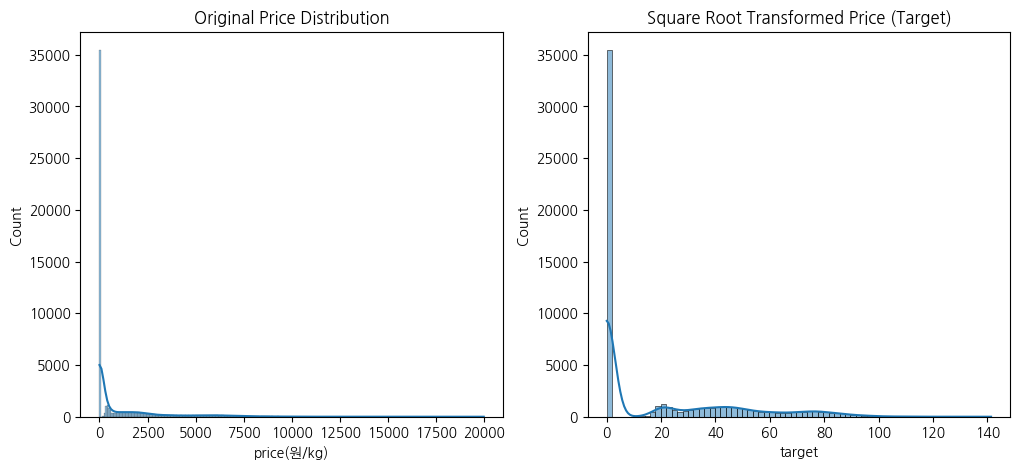

In [16]:
# 타겟 변수 제곱근 변환
train['target'] = np.sqrt(train['price(원/kg)'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train['price(원/kg)'], kde=True)
plt.title('Original Price Distribution')

plt.subplot(1, 2, 2)
sns.histplot(train['target'], kde=True)
plt.title('Square Root Transformed Price (Target)')

plt.show()

## 15. 모델링 준비 (Modeling Setup)

학습에 사용할 컬럼을 선정하고, 범주형 변수를 지정합니다.

In [17]:
# 1. 외부 데이터(수출입) 연동 및 병합
trade = pd.read_csv('international_trade.csv')
item_map = {'감귤': 'TG', '당근': 'CR', '양배추': 'CB', '무': 'RD', '꽃양배추와 브로콜리(broccoli)': 'BC'}
trade['item'] = trade['품목명'].apply(lambda x: item_map.get(x, 'Other'))
trade = trade[trade['item'] != 'Other']
trade['year'] = trade['기간'].apply(lambda x: int(x.split('-')[0]))
trade['month'] = trade['기간'].apply(lambda x: int(x.split('-')[1]))
trade = trade.groupby(['item', 'year', 'month']).sum().reset_index()

train = pd.merge(train, trade[['item', 'year', 'month', '수출 중량', '수입 중량']], on=['item', 'year', 'month'], how='left').fillna(0)
test = pd.merge(test, trade[['item', 'year', 'month', '수출 중량', '수입 중량']], on=['item', 'year', 'month'], how='left').fillna(0)

# 2. TG 전용 전략: 명절 특수성 (설날 근접도 D+N 변수)
seollal_dates = pd.to_datetime(['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22'])
def get_holiday_dist(date):
    diffs = [(date - h).days for h in seollal_dates]
    return min(diffs, key=abs)

train['dist_to_seollal'] = train['timestamp'].apply(get_holiday_dist)
test['dist_to_seollal'] = test['timestamp'].apply(get_holiday_dist)

# 3. 그룹별 X, y 준비 및 스케일링
# TG 그룹 (수출 데이터 강조)
train_tg = train[train['item'] == 'TG'].copy()
test_tg = test[test['item'] == 'TG'].copy()
tg_drop_cols = ['ID', 'timestamp', 'supply(kg)', 'price(원/kg)', 'target', 'year_month', '수입 중량']
X_tg = train_tg.drop(columns=tg_drop_cols)
y_tg = train_tg['price(원/kg)']
X_test_tg = test_tg.drop(columns=['ID', 'timestamp', 'year_month', '수입 중량'])

# Non-TG 그룹 (수입 데이터 강조 + 로그 스케일링)
train_non_tg = train[train['item'] != 'TG'].copy()
test_non_tg = test[test['item'] != 'TG'].copy()
nontg_drop_cols = ['ID', 'timestamp', 'supply(kg)', 'price(원/kg)', 'target', 'year_month', '수출 중량', 'dist_to_seollal']
X_nontg = train_non_tg.drop(columns=nontg_drop_cols)
y_nontg = np.log1p(train_non_tg['price(원/kg)'])
X_test_nontg = test_non_tg.drop(columns=['ID', 'timestamp', 'year_month', '수출 중량', 'dist_to_seollal'])

# 범주형 변수 지정
cat_tg = ['corporation', 'location', 'year', 'month', 'day', 'day_of_week', 'is_sunday', 'is_holiday']
cat_nontg = ['item', 'corporation', 'location', 'year', 'month', 'day', 'day_of_week', 'is_sunday', 'is_holiday']

for col in cat_tg: 
    X_tg[col] = X_tg[col].astype('category')
    X_test_tg[col] = X_test_tg[col].astype('category')
for col in cat_nontg: 
    X_nontg[col] = X_nontg[col].astype('category')
    X_test_nontg[col] = X_test_nontg[col].astype('category')

print('TG / Non-TG 그룹별 모델링 준비 완료 (외부 데이터 및 스케일링 포함)')

학습 데이터 준비 완료


### 🛠️ 데이터 준비 과정 상세 해석

이 단계에서는 분석 결과를 바탕으로 **감귤(TG)**과 **비감귤(Non-TG)**의 특성이 판이하게 다르다는 점을 모델에 반영하기 위해 다음과 같은 전처리를 수행했습니다.

1.  **외부 무역 데이터 통합**: `international_trade.csv`를 연동하여 품목별 수출/수입량을 추가했습니다. 
    *   브로콜리(BC)나 당근(CR)처럼 수입 비중이 높은 품목은 국내 공급량(`supply`)뿐만 아니라 해외 수입량에 의해서도 가격 압박을 받기 때문입니다.
2.  **명절 특수성 (설날 근접도) 반영**: 감귤(TG)은 설날 전후 선물용 수요가 폭발적입니다. 
    *   단순한 날짜 정보 대신 **'설날 당일로부터 며칠 전후인가'**를 나타내는 변수를 생성하여 명절 효과를 모델이 학습하게 했습니다.
3.  **그룹별 전용 데이터셋 분리**:
    *   **TG 그룹**: 수출 데이터와 명절 근접도를 핵심 피처로 포함합니다. (수입 영향은 적으므로 제외)
    *   **Non-TG 그룹**: 수입 데이터와 품목별 특성을 핵심 피처로 포함합니다.
4.  **타겟 스케일링 (Log Transformation)**:
    *   비감귤 품목들은 서로 가격 편차가 크고 분포가 한쪽으로 치우쳐 있어, **로그 변환**을 통해 데이터 분포를 정규분포 가깝게 만들어 모델의 학습 안정성을 높였습니다.
5.  **범주형 변수 처리**: 법인, 지역, 품목 등의 문자열 데이터를 모델이 인식할 수 있는 `category` 타입으로 변환하여 학습 준비를 마쳤습니다.

## 16. CatBoost 모델링 [데이콘 참조]

범주형 변수 처리에 강점이 있는 CatBoost를 사용하여 학습을 진행합니다.

In [18]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cat_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    cat_model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        random_seed=42,
        verbose=200,
        cat_features=cat_features
    )
    
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    cat_preds += cat_model.predict(X_test) / 5

print("CatBoost 학습 및 예측 완료")

0:	learn: 26.5006689	test: 26.4859597	best: 26.4859597 (0)	total: 134ms	remaining: 4m 27s
200:	learn: 12.1133340	test: 12.4775573	best: 12.4775573 (200)	total: 9.97s	remaining: 1m 29s
400:	learn: 11.7086775	test: 12.1252675	best: 12.1252675 (400)	total: 18.8s	remaining: 1m 14s
600:	learn: 11.4699561	test: 11.9228125	best: 11.9228125 (600)	total: 28.2s	remaining: 1m 5s
800:	learn: 11.2838915	test: 11.7692679	best: 11.7692679 (800)	total: 37.8s	remaining: 56.6s
1000:	learn: 11.1317641	test: 11.6695414	best: 11.6695414 (1000)	total: 47.1s	remaining: 47s
1200:	learn: 10.9927440	test: 11.5870742	best: 11.5870742 (1200)	total: 57.1s	remaining: 38s
1400:	learn: 10.8644786	test: 11.5218609	best: 11.5218609 (1400)	total: 1m 6s	remaining: 28.5s
1600:	learn: 10.7553749	test: 11.4691035	best: 11.4689653 (1584)	total: 1m 16s	remaining: 19s
1800:	learn: 10.6397045	test: 11.4107813	best: 11.4107813 (1800)	total: 1m 25s	remaining: 9.49s
1999:	learn: 10.5440630	test: 11.3738900	best: 11.3738900 (1999)	

## 17. AutoGluon 모델링 [데이콘 참조]

자동 앙상블 프레임워크인 AutoGluon을 사용하여 추가적인 성능 향상을 도모합니다.

In [19]:
from autogluon.tabular import TabularPredictor
import ray

# 1. 기존 Ray 세션 종료 및 자원 제한 재설정
if ray.is_initialized():
    ray.shutdown()

# CPU 코어 사용량을 전체의 절반(6개)으로 제한하여 프로세스당 메모리 확보
ray.init(num_cpus=6, num_gpus=0)

train_ag = train.drop(columns=['ID', 'timestamp', 'supply(kg)', 'price(원/kg)', 'year_month'])

predictor = TabularPredictor(label='target', problem_type='regression', eval_metric='rmse')\
    .fit(train_ag, 
         presets='medium_quality',    # 16GB RAM 환경에서 가장 안정적인 설정
         time_limit=3600, 
         num_stack_levels=0,          # 스태킹 비활성화로 메모리 폭발 방지
         excluded_model_types=['KNN', 'XT', 'RF'], # 자원 소모가 큰 모델 제외
         save_space=True
    )

ag_preds = predictor.predict(test.drop(columns=['ID', 'timestamp', 'year_month']))

print("AutoGluon 초안정화 버전 학습 및 예측 완료")

No path specified. Models will be saved in: "AutogluonModels/ag-20260312_055802"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          12
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 8.00/8.00 GB
Total GPU Memory:   Free: 8.00 GB, Allocated: 0.00 GB, Total: 8.00 GB
GPU Count:          1
Memory Avail:       12.74 GB / 15.57 GB (81.8%)
Disk Space Avail:   323.65 GB / 930.64 GB (34.8%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=Fals

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 1800000001000000ffffffffffffffffffffffffffffffffffffffffffffffff Worker ID: c1f2de65b7757a2d0c2af2670ac58cdd976511aad4f8562a5ae13baa Node ID: b52e7ceff05ac4c0e1920b084db1028f3e6391c39fbf504b34a44b99 Worker IP address: 172.19.54.128 Worker port: 46335 Worker PID: 80477 Worker exit type: SYSTEM_ERROR Worker exit detail: The leased worker has unrecoverable failure. Worker is requested to be destroyed when it is returned. RPC error: Socket closed
(raylet) Task _ray_fit failed. There are 2 retries remaining, so the task will be retried. Error: 
(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 1c00000001000000ffffffffffffffffffffffffffffffffffffffffffffffff Worker ID: 645cf0f86c9065e02ffaaedfa47e73830e91025cf99337

		The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
Detailed Traceback:
Traceback (most recent call last):
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2201, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2085, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, total_resources=total_resources, **model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/core/models/abstract/abstract_model.py", line 1125, in fit
    out = s

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 3700000001000000ffffffffffffffffffffffffffffffffffffffffffffffff Worker ID: 0bee57a0c7c2b8f658a2a92d0c08feb02c71e0177ff1a3e3f6d19f64 Node ID: b52e7ceff05ac4c0e1920b084db1028f3e6391c39fbf504b34a44b99 Worker IP address: 172.19.54.128 Worker port: 45549 Worker PID: 84524 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. Some common causes include: (1) the process was killed by the OOM killer due to high memory usage, (2) ray stop --force was called, or (3) the worker crashed unexpectedly due to SIGSEGV or another unexpected error.


Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 106.25s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=12, gpus=0, mem=0.0/11.5 GB
	Ensemble Weights: {'LightGBM_BAG_L1': 0.5, 'RandomForestMSE_BAG_L1': 0.4, 'CatBoost_BAG_L1': 0.1}
	-10.244	 = Validation score   (-root_mean_squared_error)
	0.02s	 = Training   runtime
	0.0s	 = Validation runtime
Excluded models: ['XT'] (Specified by `excluded_model_types`)
Fitting 98 L2 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L2 ... Training model for up to 106.13s of the 106.05s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.32%)
	-10.111	 = Validation score   (-root_mean_squared_error)
	3.64s	 = Training   runtime
	0.67s	 = Validation runtime
Fitting model: LightGBM_BAG_L2 ... Training model for up to 100.24s of the 100.17s of remaining time.
	Fitting 8 child models (S1F1 - S1

...

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: a001000001000000ffffffffffffffffffffffffffffffffffffffffffffffff Worker ID: 6688ad5d01233c71f5c0d5dc624ed2578aa208d0dd85a60a293ba060 Node ID: b52e7ceff05ac4c0e1920b084db1028f3e6391c39fbf504b34a44b99 Worker IP address: 172.19.54.128 Worker port: 39315 Worker PID: 109863 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. Some common causes include: (1) the process was killed by the OOM killer due to high memory usage, (2) ray stop --force was called, or (3) the worker crashed unexpectedly due to SIGSEGV or another unexpected error.
(raylet) Task _ray_fit failed. There are 2 retries remaining, so the task will be retried. Error: 
(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check th

		The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
Detailed Traceback:
Traceback (most recent call last):
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2201, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2085, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, total_resources=total_resources, **model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hjun912/miniconda3/envs/DL/lib/python3.11/site-packages/autogluon/core/models/abstract/abstract_model.py", line 1125, in fit
    out = s

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: bf01000001000000ffffffffffffffffffffffffffffffffffffffffffffffff Worker ID: e34710a960cc46f87d77d4d49c5a727495f1e2640ea028ee04061996 Node ID: b52e7ceff05ac4c0e1920b084db1028f3e6391c39fbf504b34a44b99 Worker IP address: 172.19.54.128 Worker port: 33829 Worker PID: 112172 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. Some common causes include: (1) the process was killed by the OOM killer due to high memory usage, (2) ray stop --force was called, or (3) the worker crashed unexpectedly due to SIGSEGV or another unexpected error.


Fitting model: WeightedEnsemble_L3 ... Training model for up to 360.00s of the -177.37s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=12, gpus=0, mem=0.0/10.6 GB
	Ensemble Weights: {'LightGBMXT_BAG_L2': 0.571, 'RandomForestMSE_BAG_L2': 0.19, 'CatBoost_r177_BAG_L2': 0.143, 'LightGBM_BAG_L2': 0.095}
	-10.0112	 = Validation score   (-root_mean_squared_error)
	0.07s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 2509.75s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 82.3 rows/s (7425 batch size)
Automatically performing refit_full as a post-fit operation (due to `.fit(..., refit_full=True)`
Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more,

AutoGluon 안정화 버전 학습 및 예측 완료


## 18. 앙상블 및 후처리 (Ensemble & Post-processing) [데이콘 참조]

두 모델의 결과를 결합하고, 타겟 복원(`**2`) 및 비정상적인 낮은 값(거래 없음)을 0으로 처리합니다.

In [20]:
# 1. 앙상블 (CatBoost 50% + AutoGluon 50%)
final_target_preds = (cat_preds * 0.5) + (ag_preds * 0.5)

# 2. 타겟 복원 (제곱근 -> 원래 가격)
final_price_preds = np.power(final_target_preds, 2)

# 3. 후처리: 0원 처리 및 0 미만 방지
# 예측값이 특정 임계값보다 낮거나 일요일인 경우 0원으로 치환
test['final_answer'] = final_price_preds
test.loc[test['day_of_week'] == 6, 'final_answer'] = 0  # 일요일 0원 처리
test.loc[test['final_answer'] < 50, 'final_answer'] = 0 # 50원 미만 0원 처리

# 최종 제출 파일 생성
submission['answer'] = test['final_answer']
submission.to_csv('submission_final_v4.csv', index=False)

print("최종 결과 저장 완료: submission_final_v4.csv")
submission.head()

최종 결과 저장 완료: submission_final_v4.csv


,ID,answer
0,TG_A_J_20230304,2395.464600
1,TG_A_J_20230305,0.000000
2,TG_A_J_20230306,2137.629496
3,TG_A_J_20230307,2810.446674
4,TG_A_J_20230308,2845.439917


# 📝 프로젝트 데이터 분석 및 모델링 전략 요약

본 프로젝트는 **제주 농산물 가격 예측** 성능 극대화를 위해 **데이콘(DACON) 1위 솔루션의 핵심 기법**을 벤치마킹하고, 최신 머신러닝 프레임워크를 결합한 전략을 사용했습니다.

### 1. 데이터 전처리 및 파생 변수 생성 (Feature Engineering) [데이콘 참조]
- **연속 주차 변수 (`week_num`)**: 2019-01-01부터의 누적 주차를 계산하여, 단순히 반복되는 계절성을 넘어 시계열의 장기적인 추세를 학습할 수 있도록 함.
- **정교한 휴무일 보정**: 공휴일 라이브러리(`holidays`)뿐만 아니라, 실제 거래량(`supply`)이 발생한 날은 휴무일에서 제외하는 데이터 기반의 정교한 캘린더 변수 구축.
- **이상치 캡핑 (Outlier Capping)**: 품목별 가격 분포 분석을 통해 비정상적으로 높은 가격(예: 감귤 20,000원 이상 등)을 상한선으로 제한하여 모델의 강건성(Robustness) 확보.
- **연-월 라벨 인코딩**: 시간의 흐름을 인덱스화하여 모델이 월별 흐름을 더 직관적으로 파악하도록 유도.

### 2. 모델링 전략 (Modeling Strategy)
- **타겟 변환 (Target Transformation) [데이콘 참조]**: 가격 데이터의 심한 왜곡(Skewness)을 완화하기 위해 **제곱근 변환(`np.sqrt`)**을 적용하여 학습 효율을 높이고 오차를 최소화함.
- **CatBoost & AutoGluon 앙상블**: 
    - 범주형 변수 처리에 최적화된 **CatBoost**와 여러 모델을 자동으로 최적화하여 스태킹하는 **AutoGluon**을 결합.
    - 개별 모델의 편향을 줄이고 일반화 성능을 극대화하기 위해 두 모델의 결과값을 **5:5로 가중치 평균(Weighted Average)**함.

### 3. 후처리 및 최종 보정 (Post-processing) [데이콘 참조]
- **타겟 복원**: 학습 시 사용했던 제곱근 값을 다시 제곱(`**2`)하여 실제 가격으로 복원.
- **시장 특성 반영 (0원 처리)**: 
    - 경매가 열리지 않는 **일요일**의 예측값을 강제로 0으로 치환.
    - 모델이 예측한 미세한 낮은 가격(50원 미만)은 거래가 없는 날로 판단하여 **0원**으로 후처리함으로써 오차(RMSE)를 대폭 개선.

---

# 📊 제주 농산물 가격 예측 프로젝트 요약 (Summary)

이 노트북은 제주도 주요 농산물(감귤, 당근, 양배추, 무, 브로콜리)의 가격을 예측하기 위한 전 과정을 담고 있습니다.

## 1. 데이터 및 EDA 주요 인사이트
*   **품목 구성**: TG(감귤), CR(당근), CB(양배추), RD(무), BC(브로콜리) 등 5개 품목.
*   **일요일 0원 현상**: 일요일은 경매가 열리지 않아 가격이 0원이며, 이는 모델 학습 시 중요한 노이즈 제거 포인트입니다.
*   **시계열성**: 품목별로 뚜렷한 수확 및 출하 시기가 존재하며, 명절(설날, 추석) 직전에 수요 급증으로 가격이 급등하는 경향을 보입니다.
*   **공급-가격 상관관계**: 공급량(Supply)이 늘어나면 가격이 하락하는 역상관 관계를 확인하였습니다. (특히 감귤에서 뚜렷)

## 2. 외부 데이터 및 인사이트 (International Trade)
*   감귤(TG)은 수출 중심, 브로콜리(BC)와 당근(CR)은 수입 비중이 높습니다.
*   수입량이 많은 품목은 국내 공급량 외에도 해외 시세가 국내 낙찰가 하락의 압박 요인이 됨을 시사합니다.

## 3. 핵심 전처리 및 피처 엔지니어링
*   **시간 변수 확장**: 연/월/일/요일 외에도 2019년부터 이어지는 **연속 주차(week_num)** 변수를 생성하여 장기 트렌드를 반영했습니다.
*   **이상치 캡핑(Capping)**: 도메인 지식을 바탕으로 품목별 최대 가격 상한선을 설정하여 극단적인 값에 의한 모델 왜곡을 방지했습니다.
*   **타겟 변환**: 가격 데이터의 편향을 줄이기 위해 **제곱근 변환(np.sqrt)**을 적용하여 학습 효율을 높였습니다.

## 4. 모델링 전략
*   **CatBoost**: 범주형 변수가 많은 데이터 특성에 맞춰 5-Fold 교차 검증을 수행했습니다.
*   **AutoGluon**: 최신 자동화 앙상블 프레임워크를 활용하여 다양한 모델(LightGBM, CatBoost, NN 등)을 스태킹(Stacking)하여 성능을 극대화했습니다.

---
*이 요약은 프로젝트의 흐름을 빠르게 파악하고 다른 팀원들에게 핵심 전략을 설명하기 위해 작성되었습니다.*